In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F
import argparse
import SimpleITK as sitk


In [2]:
# visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251 / 255, 252 / 255, 30 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="blue", facecolor=(0, 0, 0, 0), lw=2)
    )


In [3]:
@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :]  # (B, 1, 4)

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed,  # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
        multimask_output=False,
    )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (256, 256)
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)
    return medsam_seg


In [4]:
image_file = "../../datasets/ACDC/database/training/patient001/patient001_frame12.nii.gz"
image_Gt="../../datasets/ACDC/database/training/patient001/patient001_frame12_gt.nii.gz"

image=sitk.ReadImage(image_file)
image_gt=sitk.ReadImage(image_Gt)


image_array = sitk.GetArrayFromImage(image)
image_array_gt=sitk.GetArrayFromImage(image_gt)
print(image_array.shape)

(10, 256, 216)


NiftiImageIO (0x555a8c59e630): ../../datasets/ACDC/database/training/patient001/patient001_frame12.nii.gz has unexpected scales in sform

NiftiImageIO (0x555a8c59e630): ../../datasets/ACDC/database/training/patient001/patient001_frame12.nii.gz has unexpected scales in sform

NiftiImageIO (0x555a8c3c1380): ../../datasets/ACDC/database/training/patient001/patient001_frame12_gt.nii.gz has unexpected scales in sform

NiftiImageIO (0x555a8c3c1380): ../../datasets/ACDC/database/training/patient001/patient001_frame12_gt.nii.gz has unexpected scales in sform



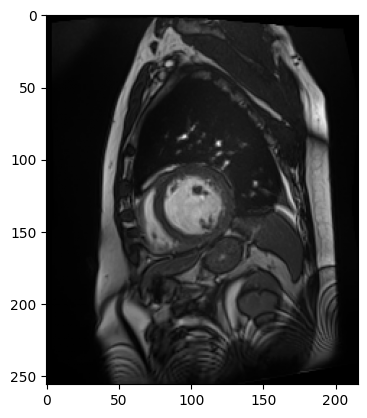

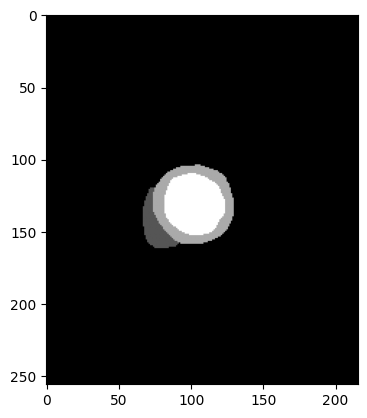

In [5]:
plt.imshow(image_array[4,:, :], cmap='gray')

plt.show()

plt.imshow(image_array_gt[4,:, :], cmap='gray')

plt.show()

In [19]:
image_array.shape

(10, 256, 216)

In [6]:
img_1024 = transform.resize(
    image_array, (10,1024, 1024), order=3, preserve_range=True, anti_aliasing=True
)

img_1024.shape

(10, 1024, 1024)

In [13]:
torch.tensor(img_1024).unsqueeze(0)

tensor([[[[1.1608e+00, 2.8809e-01, 6.9937e-03,  ..., 1.7396e-15,
           6.5826e-14, 2.2544e-13],
          [1.4694e-01, 3.6462e-02, 8.8508e-04,  ..., 2.7061e-16,
           1.0240e-14, 3.5068e-14],
          [1.4694e-01, 3.6462e-02, 8.8508e-04,  ..., 2.7061e-16,
           1.0240e-14, 3.5068e-14],
          ...,
          [5.3751e-01, 1.3344e-01, 3.2399e-03,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [5.3751e-01, 1.3344e-01, 3.2399e-03,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [5.4154e-01, 1.3448e-01, 3.2657e-03,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],

         [[3.1501e+01, 3.1202e+01, 3.1095e+01,  ..., 4.0283e-13,
           1.5243e-11, 5.2204e-11],
          [3.0808e+01, 3.0312e+01, 3.0143e+01,  ..., 6.2663e-14,
           2.3711e-12, 8.1206e-12],
          [3.0808e+01, 3.0312e+01, 3.0143e+01,  ..., 6.2663e-14,
           2.3711e-12, 8.1206e-12],
          ...,
          [1.7723e-03, 1.6657e-03, 1.6315e-03,  ..., 1.3701

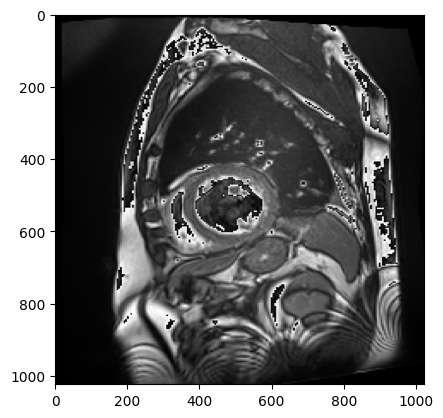

In [76]:
plt.imshow(img_1024[4,:, :], cmap='gray')

plt.show()

In [37]:
# %% load model and image
parser = argparse.ArgumentParser(
    description="run inference on testing set based on MedSAM"
)
parser.add_argument(
    "-i",
    "--data_path",
    type=str,
    default="../assets/img_demo.png",
    help="path to the data folder"
)
parser.add_argument(
    "-o",
    "--seg_path",
    type=str,
    default="assets/",
    help="path to the segmentation folder"
)
parser.add_argument(
    "--box",
    type=str,
    default='[95, 255, 190, 350]',
    help="bounding box of the segmentation target"
)
parser.add_argument("--device", type=str, default="cuda:0", help="device")
parser.add_argument(
    "-chk",
    "--checkpoint",
    type=str,
    default="../medsam_vit_b.pth",
    help="path to the trained model"
)
args = parser.parse_args([
    "--data_path", "../assets/img_demo.png",
    "--seg_path", "../assets/",
    "--box", "[60, 100, 130, 170]",
    "--device", "cuda:0",
    "--checkpoint", "../medsam_vit_b.pth",
])

In [23]:
import os

print(os.getcwd())

/home/jovyan/ thesis project/MedSAM/notebooks


In [27]:
S, H, W = image_array.shape

box_np = np.array([[int(x) for x in args.box[1:-1].split(',')]]) 
# transfer box_np t0 1024x1024 scale
box_1024 = box_np / np.array([W, H, W, H]) * 1024

box_1024

array([[450.37037037, 600.        , 900.74074074, 800.        ]])

[[284.44444444 400.         616.2962963  680.        ]]


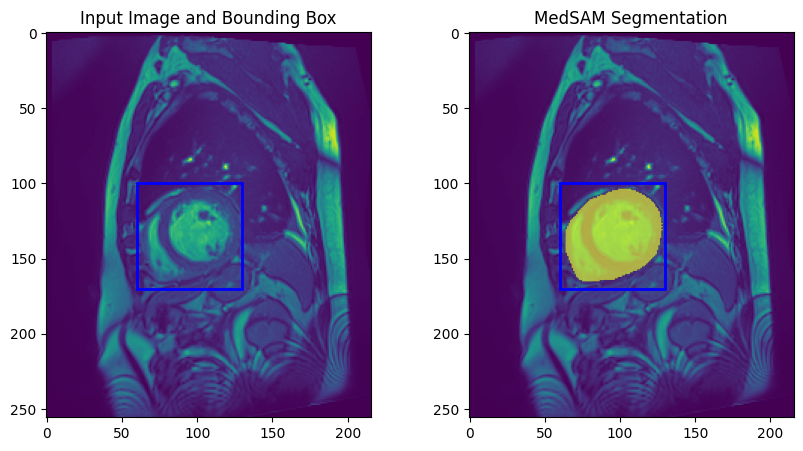

In [38]:
device = args.device
medsam_model = sam_model_registry["vit_b"](checkpoint=args.checkpoint)
medsam_model = medsam_model.to(device)
medsam_model.eval()

# img_np = io.imread(args.data_path)
# if len(img_np.shape) == 2:
#     img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
# else:
#     img_3c = img_np

S, H, W = image_array.shape


# %% image preprocessing
img_1024 = transform.resize(
    image_array, (10, 1024, 1024), order=3, preserve_range=True, anti_aliasing=True
).astype(np.uint8)
img_1024 = (img_1024 - img_1024.min()) / np.clip(
    img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None
)  # normalize to [0, 1], (S=10, H, W)

img_1024_tensor = (
    torch.tensor(img_1024).float().unsqueeze(0).to(device)    #(1,10,1024,1024)
) 

img_1024_tensor_slice=img_1024_tensor[:,4,:, :]
img_1024_tensor_slice=img_1024_tensor_slice.repeat(1,3,1,1)

box_np = np.array([[int(x) for x in args.box[1:-1].split(',')]]) 
# transfer box_np t0 1024x1024 scale
box_1024 = box_np / np.array([
    W, H, W, H]) * 1024
print(box_1024)
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_1024_tensor_slice)  # (1, 256, 64, 64)

medsam_seg = medsam_inference(medsam_model, image_embedding, box_1024, H, W)
io.imsave(
    join(args.seg_path, "seg_" + os.path.basename(args.data_path)),
    medsam_seg,
    check_contrast=False,
)

# %% visualize results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_array[4,:,:])
show_box(box_np[0], ax[0])
ax[0].set_title("Input Image and Bounding Box")
ax[1].imshow(image_array[4,:,:])
show_mask(medsam_seg, ax[1])
show_box(box_np[0], ax[1])
ax[1].set_title("MedSAM Segmentation")
plt.show()
